In [1]:
"""
异常点检测分析Notebook
用于分析同一工业缺陷类型的图片embedding分布，并识别脱离特征中心的异常数据
"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 添加项目路径
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.preprocessing import StandardScaler
import umap
from PIL import Image
import torch
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib
matplotlib.rc("font", family='AR PL UKai CN')

print("✓ 导入完成")


✓ 导入完成


In [2]:
npz_path = "../checkpoints/supcon_models/1229-2/extract_embeddings/60194-CCD1-负极.npz"
data = np.load(npz_path)
embeddings = data['embeddings']
label_names = data['label_names']
image_paths = data['image_paths']
mask_paths = data['mask_paths']

print(f"Embeddings 形状: {embeddings.shape}")
print(f"样本数量: {len(image_paths)}")
print(f"标签数量: {len(set(label_names))}")
print(f"唯一标签: {list(set(label_names))[:10]}...")  # 显示前10个标签

Embeddings 形状: (400, 128)
样本数量: 400
标签数量: 17
唯一标签: [np.str_('极柱上塑胶_色差'), np.str_('顶盖四边_碰伤'), np.str_('极柱正面_划伤'), np.str_('顶盖正面_压伤'), np.str_('顶盖正面_磨花'), np.str_('顶盖正面_笔迹'), np.str_('极柱正面_污渍'), np.str_('极柱正面_压伤'), np.str_('顶盖正面_划伤'), np.str_('顶盖正面_污渍')]...


In [3]:
idx = 20
print(f"idx: {idx}")
print(f"image_paths: {image_paths[idx]}")
print(f"label_names: {label_names[idx]}")
print(f"mask_paths: {mask_paths[idx]}")


idx: 20
image_paths: data/zhenyu_data/60194/60194-CCD1-负极/顶盖正面_划伤/37feb3ee-492e-4aba-ba21-b971d5507148_000.png
label_names: 顶盖正面_划伤
mask_paths: data/zhenyu_data/60194/60194-CCD1-负极/顶盖正面_划伤/37feb3ee-492e-4aba-ba21-b971d5507148_000_mask.png


In [4]:
# 确保 embeddings 是 numpy 数组
if not isinstance(embeddings, np.ndarray):
    embeddings = np.array(embeddings)

# 确保所有路径都是字符串格式
def decode_if_bytes(x):
    """如果是 bytes 类型，解码为字符串"""
    if isinstance(x, bytes):
        return x.decode('utf-8')
    return str(x)

# 转换路径格式
image_paths = [decode_if_bytes(p) for p in image_paths]
mask_paths = [decode_if_bytes(p) for p in mask_paths]
label_names = [decode_if_bytes(l) for l in label_names]

# 验证数据一致性
assert len(image_paths) == len(mask_paths) == len(label_names) == len(embeddings), \
    f"数据长度不一致: images={len(image_paths)}, masks={len(mask_paths)}, labels={len(label_names)}, embeddings={len(embeddings)}"

print(f"✓ 数据预处理完成")
print(f"  - 样本数: {len(image_paths)}")
print(f"  - Embedding 维度: {embeddings.shape[1]}")
print(f"  - 唯一标签数: {len(set(label_names))}")

✓ 数据预处理完成
  - 样本数: 400
  - Embedding 维度: 128
  - 唯一标签数: 17


In [5]:
unique_labels = list(set(label_names))
unique_labels.sort()
print(f"Total unique labels: {len(unique_labels)}")
print(f"Unique labels: {unique_labels[:10]}...")  # 显示前10个

# 为每个类别创建索引映射
label_to_indices = {}
label_to_embeddings = {}

for label in unique_labels:
    indices = [i for i, lb in enumerate(label_names) if lb == label]
    label_to_indices[label] = indices
    label_to_embeddings[label] = embeddings[indices]
    
print(f"\n类别样本分布:")
for label in unique_labels[:20]:  # 显示前20个类别
    print(f"  {label}: {len(label_to_indices[label])} 个样本")
if len(unique_labels) > 20:
    print(f"  ... 还有 {len(unique_labels) - 20} 个类别")
    
print(f"\n✓ 类别索引映射完成")

Total unique labels: 17
Unique labels: ['极柱_金属丝', '极柱_金属屑', '极柱上塑胶_破损', '极柱上塑胶_色差', '极柱正面_划伤', '极柱正面_压伤', '极柱正面_异物', '极柱正面_污渍', '极柱正面_磨花', '极柱正面_笔迹']...

类别样本分布:
  极柱_金属丝: 17 个样本
  极柱_金属屑: 9 个样本
  极柱上塑胶_破损: 19 个样本
  极柱上塑胶_色差: 8 个样本
  极柱正面_划伤: 3 个样本
  极柱正面_压伤: 13 个样本
  极柱正面_异物: 6 个样本
  极柱正面_污渍: 12 个样本
  极柱正面_磨花: 53 个样本
  极柱正面_笔迹: 7 个样本
  极柱正面_缺口: 31 个样本
  顶盖四边_碰伤: 44 个样本
  顶盖正面_划伤: 19 个样本
  顶盖正面_压伤: 33 个样本
  顶盖正面_污渍: 29 个样本
  顶盖正面_磨花: 43 个样本
  顶盖正面_笔迹: 54 个样本

✓ 类别索引映射完成


In [6]:
class OutlierDetector:
    """异常点检测器 - 基于embedding分布检测异常点"""
    
    def __init__(self, embeddings: np.ndarray):
        """
        Args:
            embeddings: (N, D) embedding向量
        """
        self.embeddings = embeddings
        self.n_samples, self.n_features = embeddings.shape
        
        # 计算中心点
        self.center = np.mean(embeddings, axis=0)
        
        # 计算协方差矩阵（用于马氏距离）
        self.cov = np.cov(embeddings.T)
        # 添加正则化防止奇异
        self.cov += np.eye(self.cov.shape[0]) * 1e-6
        try:
            self.cov_inv = np.linalg.inv(self.cov)
        except:
            # 如果仍然奇异，使用伪逆
            self.cov_inv = np.linalg.pinv(self.cov)
    
    def detect_by_distance(self, threshold_percentile: float = 95.0):
        """
        基于到中心的欧氏距离检测异常点
        """
        distances = np.linalg.norm(self.embeddings - self.center, axis=1)
        threshold = np.percentile(distances, threshold_percentile)
        is_outlier = distances > threshold
        return is_outlier, distances, threshold
    
    def detect_by_cosine_distance(self, threshold_percentile: float = 95.0):
        """
        基于到中心的余弦距离检测异常点
        """
        # 计算每个embedding与中心的余弦相似度
        center_normalized = self.center / (np.linalg.norm(self.center) + 1e-8)
        similarities = self.embeddings @ center_normalized
        cosine_distances = 1 - similarities  # 转换为距离
        threshold = np.percentile(cosine_distances, threshold_percentile)
        is_outlier = cosine_distances > threshold
        return is_outlier, cosine_distances, threshold
    
    def detect_by_mahalanobis(self, threshold_percentile: float = 95.0):
        """
        基于马氏距离检测异常点（考虑协方差结构）
        """
        diff = self.embeddings - self.center
        mahalanobis_distances = np.sqrt(np.sum(diff @ self.cov_inv * diff, axis=1))
        threshold = np.percentile(mahalanobis_distances, threshold_percentile)
        is_outlier = mahalanobis_distances > threshold
        return is_outlier, mahalanobis_distances, threshold
    
    def detect_by_isolation_forest(self, contamination: float = 0.05, random_state: int = 42):
        """
        基于Isolation Forest检测异常点
        """
        model = IsolationForest(
            contamination=contamination,
            random_state=random_state,
            n_estimators=100
        )
        is_outlier = model.fit_predict(self.embeddings) == -1
        scores = model.score_samples(self.embeddings)
        threshold = np.percentile(scores, (1 - contamination) * 100)
        return is_outlier, scores, threshold
    
    def detect_by_lof(self, n_neighbors: int = 20, contamination: float = 0.05):
        """
        基于Local Outlier Factor (LOF)检测异常点
        """
        n_neighbors = min(n_neighbors, self.n_samples - 1)
        model = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            contamination=contamination,
            novelty=False
        )
        is_outlier = model.fit_predict(self.embeddings) == -1
        scores = -model.negative_outlier_factor_  # 转换为正数，越大越异常
        threshold = np.percentile(scores, (1 - contamination) * 100)
        return is_outlier, scores, threshold

print("✓ 异常点检测器定义完成")


✓ 异常点检测器定义完成


In [16]:
def compute_robust_center(embeddings, method='trimmed_mean', trim_ratio=0.1):
    """
    计算鲁棒的类别中心，避免被异常点影响
    
    Args:
        embeddings: (N, D) embedding向量
        method: 'trimmed_mean' | 'median' | 'iterative'
        trim_ratio: 对于trimmed_mean方法，去除的极端值比例
    
    Returns:
        center: (D,) 类别中心向量
    """
    if len(embeddings) < 5:
        # 样本太少，直接用均值
        return np.mean(embeddings, axis=0)
    
    if method == 'median':
        # 使用中位数（对异常值更鲁棒）
        center = np.median(embeddings, axis=0)
        
    elif method == 'trimmed_mean':
        # 修剪均值：去除距离最远的一部分样本后计算均值
        # 1. 先计算初步中心
        initial_center = np.mean(embeddings, axis=0)
        # 2. 计算每个样本到初步中心的距离
        distances = np.linalg.norm(embeddings - initial_center, axis=1)
        # 3. 排序并去除距离最远的trim_ratio比例的样本
        n_trim = int(len(embeddings) * trim_ratio)
        if n_trim > 0:
            sorted_indices = np.argsort(distances)
            kept_indices = sorted_indices[:-n_trim]
            center = np.mean(embeddings[kept_indices], axis=0)
        else:
            center = initial_center
            
    elif method == 'iterative':
        # 迭代方法：多次去除异常点并重新计算中心
        current_embeddings = embeddings.copy()
        for iteration in range(3):  # 最多迭代3次
            center = np.mean(current_embeddings, axis=0)
            distances = np.linalg.norm(current_embeddings - center, axis=1)
            # 只保留距离在95%分位数以内的样本
            threshold = np.percentile(distances, 95)
            mask = distances <= threshold
            if np.sum(mask) < len(current_embeddings) * 0.5:
                # 如果剩余样本太少，停止迭代
                break
            current_embeddings = current_embeddings[mask]
        center = np.mean(current_embeddings, axis=0)
    
    else:
        # 默认使用普通均值
        center = np.mean(embeddings, axis=0)
    
    return center


# 计算每个类别的鲁棒中心embedding
print("=" * 80)
print("计算类别中心embedding（使用鲁棒方法避免异常值影响）")
print("=" * 80)

label_centers = {}
center_method = 'trimmed_mean'  # 可选: 'median', 'trimmed_mean', 'iterative'
trim_ratio = 0.1  # 去除10%的极端样本

for label in tqdm(unique_labels, desc="计算类别中心"):
    label_embeddings = label_to_embeddings[label]
    
    # L2归一化
    label_embeddings_norm = F.normalize(torch.from_numpy(label_embeddings), dim=1, p=2).numpy()
    
    # 使用鲁棒方法计算中心
    center = compute_robust_center(label_embeddings_norm, method=center_method, trim_ratio=trim_ratio)
    
    # 归一化中心
    center = center / (np.linalg.norm(center) + 1e-8)
    label_centers[label] = center

print(f"\n✓ 已计算 {len(label_centers)} 个类别的鲁棒中心embedding")
print(f"  使用方法: {center_method}")
if center_method == 'trimmed_mean':
    print(f"  修剪比例: {trim_ratio*100:.1f}% (去除最远的样本)")

def find_most_similar_label(embedding, current_label, label_centers, top_k=3):
    """
    找到与给定embedding最相似的其他类别
    
    Args:
        embedding: 目标embedding向量
        current_label: 当前类别（排除该类别）
        label_centers: 所有类别的中心embedding字典
        top_k: 返回前k个最相似的类别
    
    Returns:
        List of (label, similarity_score) tuples
    """
    similarities = []
    for label, center in label_centers.items():
        if label == current_label:
            continue
        # 计算余弦相似度
        similarity = np.dot(embedding, center)
        similarities.append((label, float(similarity)))
    
    # 按相似度降序排序
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

print("✓ 相似度计算函数定义完成")

计算类别中心embedding（使用鲁棒方法避免异常值影响）


计算类别中心: 100%|██████████| 17/17 [00:00<00:00, 5631.27it/s]


✓ 已计算 17 个类别的鲁棒中心embedding
  使用方法: trimmed_mean
  修剪比例: 10.0% (去除最远的样本)
✓ 相似度计算函数定义完成


# 执行异常点检测


In [17]:
# 配置参数
OUTLIER_THRESHOLD_PERCENTILE = 95.0  # 异常点阈值百分位数
CONTAMINATION = (100 - OUTLIER_THRESHOLD_PERCENTILE) / 100.0  # 污染率
MIN_SAMPLES_FOR_DETECTION = 10  # 最少样本数才进行异常检测

# 存储所有类别的异常检测结果
all_results = {}

print("=" * 80)
print("开始对每个类别进行类内异常点检测...")
print("=" * 80)

for label in tqdm(unique_labels, desc="处理类别"):
    indices = label_to_indices[label]
    label_embeddings = label_to_embeddings[label]
    
    # 样本数太少，跳过
    if len(indices) < MIN_SAMPLES_FOR_DETECTION:
        print(f"\n⚠️  {label}: 样本数不足({len(indices)} < {MIN_SAMPLES_FOR_DETECTION})，跳过")
        continue
    
    # L2归一化
    embeddings_normalized = F.normalize(torch.from_numpy(label_embeddings), dim=1, p=2).numpy()
    
    # 初始化检测器
    detector = OutlierDetector(embeddings_normalized)
    
    # 执行多种检测方法
    results = {}
    
    # 1. 欧氏距离方法
    is_outlier, scores, threshold = detector.detect_by_distance(OUTLIER_THRESHOLD_PERCENTILE)
    results['distance'] = {
        'is_outlier': is_outlier,
        'scores': scores,
        'threshold': threshold,
        'n_outliers': np.sum(is_outlier)
    }
    
    # 2. 余弦距离方法
    is_outlier, scores, threshold = detector.detect_by_cosine_distance(OUTLIER_THRESHOLD_PERCENTILE)
    results['cosine'] = {
        'is_outlier': is_outlier,
        'scores': scores,
        'threshold': threshold,
        'n_outliers': np.sum(is_outlier)
    }
    
    # 3. 马氏距离方法
    is_outlier, scores, threshold = detector.detect_by_mahalanobis(OUTLIER_THRESHOLD_PERCENTILE)
    results['mahalanobis'] = {
        'is_outlier': is_outlier,
        'scores': scores,
        'threshold': threshold,
        'n_outliers': np.sum(is_outlier)
    }
    
    # 4. Isolation Forest
    is_outlier, scores, threshold = detector.detect_by_isolation_forest(contamination=CONTAMINATION)
    results['isolation_forest'] = {
        'is_outlier': is_outlier,
        'scores': scores,
        'threshold': threshold,
        'n_outliers': np.sum(is_outlier)
    }
    
    # 5. LOF方法
    is_outlier, scores, threshold = detector.detect_by_lof(contamination=CONTAMINATION)
    results['lof'] = {
        'is_outlier': is_outlier,
        'scores': scores,
        'threshold': threshold,
        'n_outliers': np.sum(is_outlier)
    }
    
    # 综合多种方法的结果（投票机制）
    outlier_votes = np.zeros(len(embeddings_normalized), dtype=int)
    for method_name, result in results.items():
        outlier_votes += result['is_outlier'].astype(int)
    
    # 计算综合异常分数（归一化到0-1）
    outlier_scores_combined = outlier_votes / len(results)
    
    # 设置综合异常点阈值（至少两种及以上方法认为是异常点）
    threshold_votes = 2
    is_outlier_combined = outlier_votes >= threshold_votes
    
    # 保存综合结果
    results['combined'] = {
        'is_outlier': is_outlier_combined,
        'scores': outlier_scores_combined,
        'votes': outlier_votes,
        'n_outliers': np.sum(is_outlier_combined)
    }
    
    # 保存该类别的所有结果
    all_results[label] = {
        'indices': indices,  # 原始数据中的索引
        'embeddings_normalized': embeddings_normalized,
        'results': results
    }

print("\n" + "=" * 80)
print(f"✓ 异常点检测完成，共处理 {len(all_results)} 个类别")
print("=" * 80)

开始对每个类别进行类内异常点检测...


处理类别:   6%|▌         | 1/17 [00:00<00:01,  9.79it/s]


⚠️  极柱_金属屑: 样本数不足(9 < 10)，跳过


处理类别:  18%|█▊        | 3/17 [00:00<00:00, 15.47it/s]


⚠️  极柱上塑胶_色差: 样本数不足(8 < 10)，跳过

⚠️  极柱正面_划伤: 样本数不足(3 < 10)，跳过


...


⚠️  极柱正面_异物: 样本数不足(6 < 10)，跳过


处理类别:  65%|██████▍   | 11/17 [00:00<00:00, 14.67it/s]


⚠️  极柱正面_笔迹: 样本数不足(7 < 10)，跳过


处理类别: 100%|██████████| 17/17 [00:01<00:00, 11.74it/s]


✓ 异常点检测完成，共处理 12 个类别


In [18]:
# 为每个类别的异常点找到最相似的其他类别
print("=" * 80)
print("为异常点寻找最相似的类别...")
print("=" * 80)

outlier_analysis = []

for label, data in tqdm(all_results.items(), desc="分析异常点"):
    indices = data['indices']
    embeddings_norm = data['embeddings_normalized']
    results = data['results']
    
    # 获取异常点
    outlier_mask = results['combined']['is_outlier']
    outlier_local_indices = np.where(outlier_mask)[0]
    
    if len(outlier_local_indices) == 0:
        continue
    
    # 对每个异常点，找到最相似的其他类别
    for local_idx in outlier_local_indices:
        global_idx = indices[local_idx]
        embedding = embeddings_norm[local_idx]
        outlier_score = results['combined']['scores'][local_idx]
        votes = results['combined']['votes'][local_idx]
        
        # 找到最相似的3个其他类别
        similar_labels = find_most_similar_label(embedding, label, label_centers, top_k=3)
        
        outlier_analysis.append({
            'label': label,
            'global_index': int(global_idx),
            'local_index': int(local_idx),
            'image_path': image_paths[global_idx],
            'mask_path': mask_paths[global_idx],
            'outlier_score': float(outlier_score),
            'votes': int(votes),
            'most_similar_labels': similar_labels
        })

# 按异常分数排序
outlier_analysis.sort(key=lambda x: x['outlier_score'], reverse=True)

print(f"\n✓ 共发现 {len(outlier_analysis)} 个异常点")
print(f"  涉及 {len(set([x['label'] for x in outlier_analysis]))} 个类别")

# 统计每个类别的异常点数量
label_outlier_counts = {}
for item in outlier_analysis:
    label = item['label']
    label_outlier_counts[label] = label_outlier_counts.get(label, 0) + 1

print(f"\n各类别异常点数量 (前20个):")
sorted_counts = sorted(label_outlier_counts.items(), key=lambda x: x[1], reverse=True)
for label, count in sorted_counts[:20]:
    total = len(label_to_indices[label])
    print(f"  {label}: {count}/{total} ({count/total*100:.1f}%)")
if len(sorted_counts) > 20:
    print(f"  ... 还有 {len(sorted_counts) - 20} 个类别")

为异常点寻找最相似的类别...


分析异常点: 100%|██████████| 12/12 [00:00<00:00, 15857.48it/s]


✓ 共发现 28 个异常点
  涉及 12 个类别

各类别异常点数量 (前20个):
  极柱正面_磨花: 5/53 (9.4%)
  顶盖四边_碰伤: 3/44 (6.8%)
  顶盖正面_磨花: 3/43 (7.0%)
  顶盖正面_笔迹: 3/54 (5.6%)
  顶盖正面_污渍: 3/29 (10.3%)
  极柱正面_缺口: 2/31 (6.5%)
  顶盖正面_压伤: 2/33 (6.1%)
  极柱正面_压伤: 2/13 (15.4%)
  顶盖正面_划伤: 2/19 (10.5%)
  极柱正面_污渍: 1/12 (8.3%)
  极柱上塑胶_破损: 1/19 (5.3%)
  极柱_金属丝: 1/17 (5.9%)


# 显示异常点结果


In [19]:
# 显示异常点分析结果
print("=" * 100)
print("异常点详细分析结果")
print("=" * 100)

print(f"\n前30个最异常的样本:")
print("-" * 100)

for i, item in enumerate(outlier_analysis[:30], 1):
    print(f"\n{i:2d}. 【{item['label']}】")
    print(f"    全局索引: {item['global_index']}, 类内索引: {item['local_index']}")
    print(f"    异常分数: {item['outlier_score']:.3f}, 投票数: {item['votes']}/5")
    print(f"    图片路径: {item['image_path']}")
    print(f"    最相似的其他类别:")
    for rank, (sim_label, sim_score) in enumerate(item['most_similar_labels'], 1):
        print(f"      {rank}. {sim_label} (相似度: {sim_score:.4f})")

if len(outlier_analysis) > 30:
    print(f"\n... 还有 {len(outlier_analysis) - 30} 个异常样本")

print("\n" + "=" * 100)

异常点详细分析结果

前30个最异常的样本:
----------------------------------------------------------------------------------------------------

 1. 【极柱正面_缺口】
    全局索引: 46, 类内索引: 16
    异常分数: 1.000, 投票数: 5/5
    图片路径: data/zhenyu_data/60194/60194-CCD1-负极/极柱正面_缺口/4a86939a-bfc7-471c-9c88-7d2a6b8f9f41_000.png
    最相似的其他类别:
      1. 顶盖正面_污渍 (相似度: 0.9132)
      2. 极柱正面_污渍 (相似度: 0.8487)
      3. 极柱正面_磨花 (相似度: 0.6809)

 2. 【顶盖四边_碰伤】
    全局索引: 138, 类内索引: 3
    异常分数: 1.000, 投票数: 5/5
    图片路径: data/zhenyu_data/60194/60194-CCD1-负极/顶盖四边_碰伤/f0c3a74d-9edd-4186-be4e-dfe3c802d088_000.png
    最相似的其他类别:
      1. 极柱正面_异物 (相似度: 0.4379)
      2. 极柱正面_磨花 (相似度: 0.4314)
      3. 极柱上塑胶_破损 (相似度: 0.4276)

 3. 【顶盖四边_碰伤】
    全局索引: 154, 类内索引: 19
    异常分数: 1.000, 投票数: 5/5
    图片路径: data/zhenyu_data/60194/60194-CCD1-负极/顶盖四边_碰伤/5f863deb-2da5-440a-b150-27b3abd11b37_000.png
    最相似的其他类别:
      1. 顶盖正面_污渍 (相似度: 0.6826)
      2. 极柱正面_污渍 (相似度: 0.5868)
      3. 极柱正面_磨花 (相似度: 0.4924)

 4. 【顶盖四边_碰伤】
    全局索引: 164, 类内索引: 29
    异常分数: 1.000, 投票数: 

可视化异常点最多的 6 个类别...


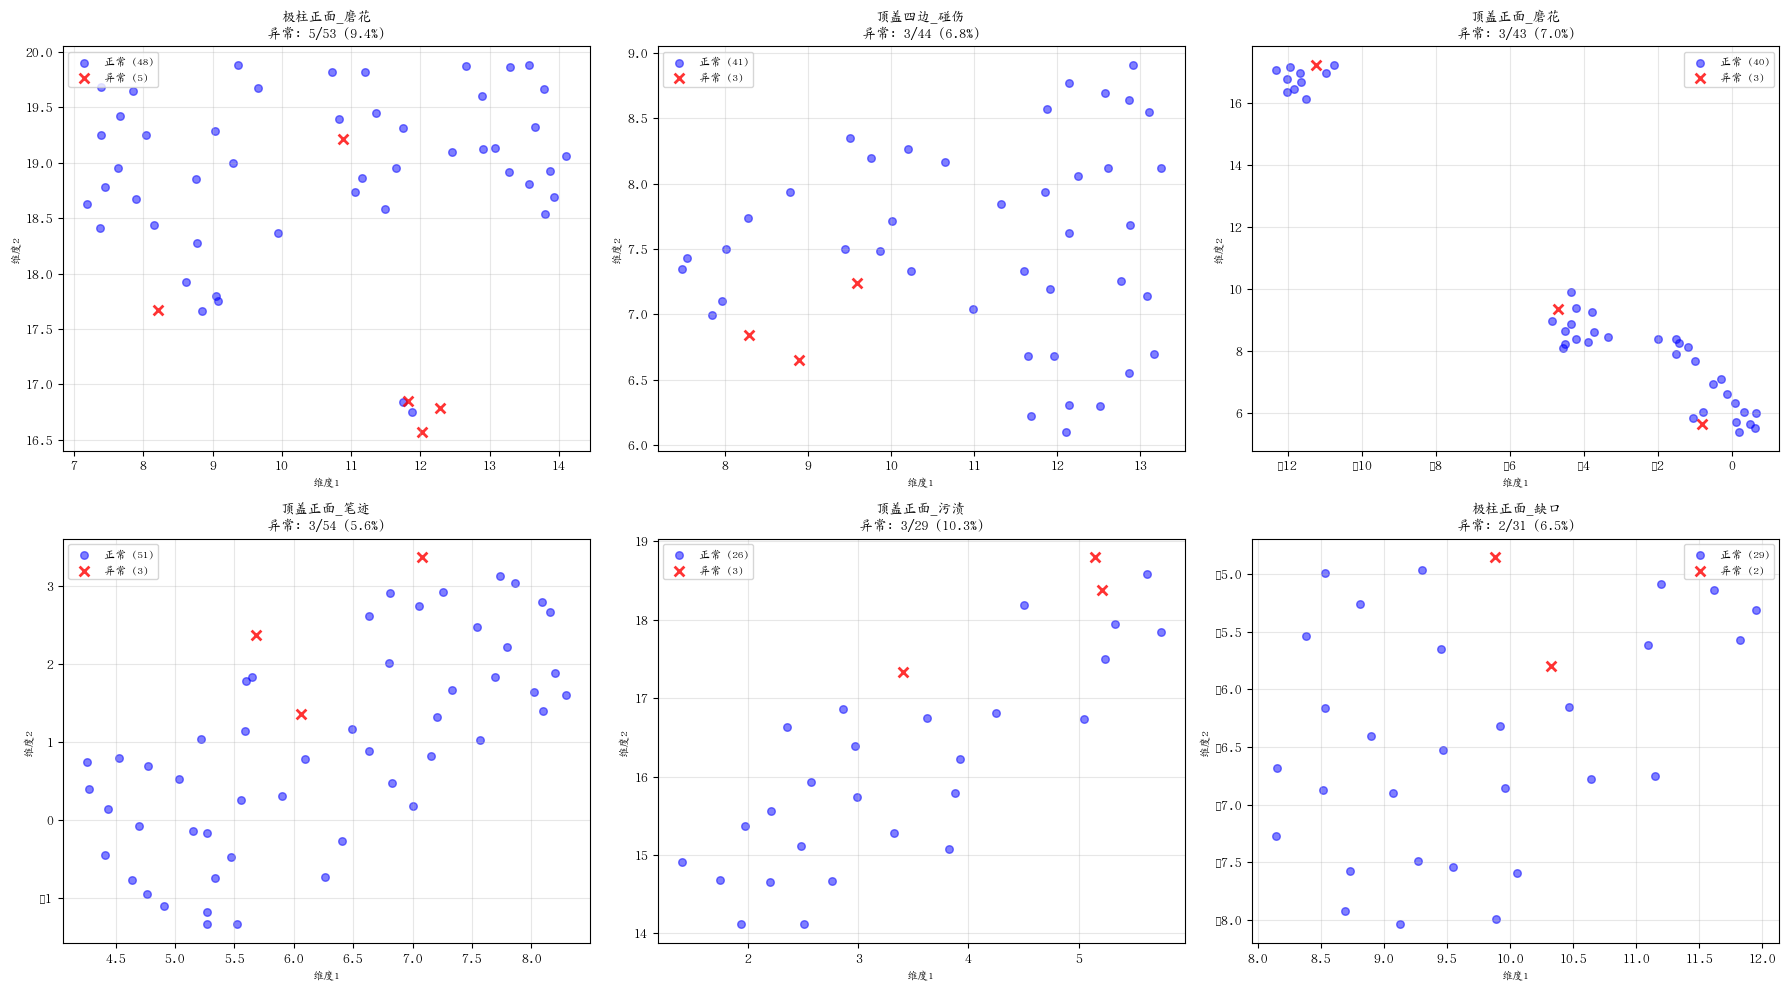

In [20]:
# 选择异常点最多的几个类别进行可视化
top_n_categories = 6
top_categories = sorted_counts[:top_n_categories]

print(f"可视化异常点最多的 {top_n_categories} 个类别...")

# 对选中的类别进行UMAP降维和可视化
n_cols = 3
n_rows = (top_n_categories + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
if top_n_categories == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (label, outlier_count) in enumerate(top_categories):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    
    # 获取该类别的数据
    data = all_results[label]
    embeddings_norm = data['embeddings_normalized']
    results = data['results']
    
    # UMAP降维
    if len(embeddings_norm) >= 15:
        n_neighbors = min(15, len(embeddings_norm) - 1)
        reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine', n_neighbors=n_neighbors)
        embeddings_2d = reducer.fit_transform(embeddings_norm)
    else:
        # 样本太少，用PCA
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2, random_state=42)
        embeddings_2d = pca.fit_transform(embeddings_norm)
    
    # 绘制
    normal_mask = ~results['combined']['is_outlier']
    outlier_mask = results['combined']['is_outlier']
    
    ax.scatter(
        embeddings_2d[normal_mask, 0], 
        embeddings_2d[normal_mask, 1],
        c='blue', alpha=0.5, s=30, label=f'正常 ({np.sum(normal_mask)})'
    )
    ax.scatter(
        embeddings_2d[outlier_mask, 0], 
        embeddings_2d[outlier_mask, 1],
        c='red', alpha=0.8, s=50, marker='x', linewidths=2, label=f'异常 ({np.sum(outlier_mask)})'
    )
    
    total = len(embeddings_norm)
    ax.set_title(f'{label}\n异常: {outlier_count}/{total} ({outlier_count/total*100:.1f}%)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('维度1', fontsize=8)
    ax.set_ylabel('维度2', fontsize=8)

# 隐藏多余的子图
for idx in range(top_n_categories, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# 按类别可视化异常点

# 可视化：异常点分布


执行全局UMAP降维（包含所有类别）...
✓ 全局UMAP降维完成


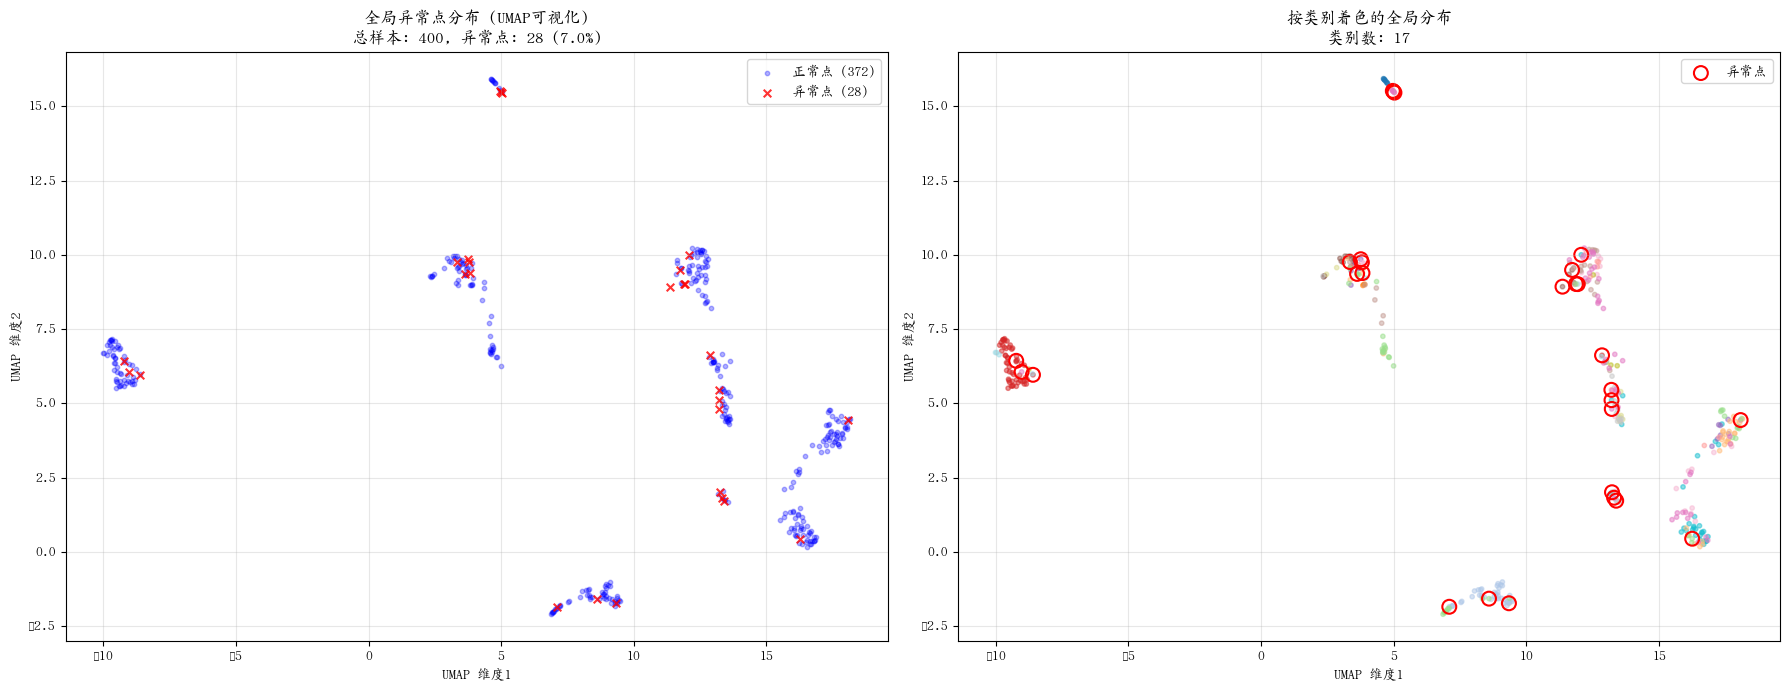

In [21]:
# 使用UMAP降维可视化所有数据（整体视角）
print("执行全局UMAP降维（包含所有类别）...")

# L2归一化所有embeddings
all_embeddings_norm = F.normalize(torch.from_numpy(embeddings), dim=1, p=2).numpy()

reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    metric='cosine',
    n_neighbors=min(15, len(all_embeddings_norm) - 1)
)
embeddings_2d_global = reducer.fit_transform(all_embeddings_norm)
print("✓ 全局UMAP降维完成")

# 创建全局异常点标记（根据类内检测结果）
is_global_outlier = np.zeros(len(embeddings), dtype=bool)
for label, data in all_results.items():
    indices = data['indices']
    outlier_mask = data['results']['combined']['is_outlier']
    # 标记全局异常点
    outlier_indices = np.array(indices)[outlier_mask]
    is_global_outlier[outlier_indices] = True

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 左图: 所有类别的异常点分布
normal_mask = ~is_global_outlier
outlier_mask = is_global_outlier

axes[0].scatter(
    embeddings_2d_global[normal_mask, 0], 
    embeddings_2d_global[normal_mask, 1],
    c='blue', alpha=0.3, s=10, label=f'正常点 ({np.sum(normal_mask)})'
)
axes[0].scatter(
    embeddings_2d_global[outlier_mask, 0], 
    embeddings_2d_global[outlier_mask, 1],
    c='red', alpha=0.8, s=30, marker='x', label=f'异常点 ({np.sum(outlier_mask)})'
)
axes[0].set_title(f'全局异常点分布 (UMAP可视化)\n总样本: {len(embeddings)}, 异常点: {np.sum(outlier_mask)} ({np.sum(outlier_mask)/len(embeddings)*100:.1f}%)')
axes[0].set_xlabel('UMAP 维度1')
axes[0].set_ylabel('UMAP 维度2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图: 按类别着色
unique_labels_subset = list(set(label_names))
# 为每个类别分配颜色
label_to_color = {label: i for i, label in enumerate(unique_labels_subset)}
colors = [label_to_color[lb] for lb in label_names]

scatter = axes[1].scatter(
    embeddings_2d_global[:, 0], 
    embeddings_2d_global[:, 1],
    c=colors, cmap='tab20', s=10, alpha=0.5
)
# 标记异常点
axes[1].scatter(
    embeddings_2d_global[outlier_mask, 0], 
    embeddings_2d_global[outlier_mask, 1],
    facecolors='none', edgecolors='red', s=100, linewidths=1.5, marker='o', label='异常点'
)
axes[1].set_title(f'按类别着色的全局分布\n类别数: {len(unique_labels_subset)}')
axes[1].set_xlabel('UMAP 维度1')
axes[1].set_ylabel('UMAP 维度2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 可视化：各方法检测结果对比


# 可视化：异常分数分布


In [22]:
# 分析异常点可能被错误标注的情况
# 如果异常点与其最相似的类别相似度很高，可能说明该样本被标注错了

print("=" * 100)
print("可能被错误标注的样本分析")
print("=" * 100)

# 设置高相似度阈值
HIGH_SIMILARITY_THRESHOLD = 0.8  # 与其他类别相似度超过此值认为可能标注错误

suspicious_samples = []

for item in outlier_analysis:
    # 检查与最相似类别的相似度
    if len(item['most_similar_labels']) > 0:
        most_similar_label, similarity = item['most_similar_labels'][0]
        if similarity >= HIGH_SIMILARITY_THRESHOLD:
            suspicious_samples.append({
                **item,
                'suggested_label': most_similar_label,
                'similarity_to_suggested': similarity
            })

print(f"\n发现 {len(suspicious_samples)} 个可能被错误标注的样本 (相似度 >= {HIGH_SIMILARITY_THRESHOLD})")
print(f"占所有异常点的 {len(suspicious_samples)/len(outlier_analysis)*100:.1f}%\n")

# 按相似度降序显示
suspicious_samples.sort(key=lambda x: x['similarity_to_suggested'], reverse=True)

print(f"前20个最可疑的样本:")
print("-" * 100)

for i, item in enumerate(suspicious_samples[:20], 1):
    print(f"\n{i:2d}. 当前标签: 【{item['label']}】")
    print(f"    建议标签: 【{item['suggested_label']}】 (相似度: {item['similarity_to_suggested']:.4f})")
    print(f"    异常分数: {item['outlier_score']:.3f}, 投票数: {item['votes']}/5")
    print(f"    图片路径: {item['image_path']}")
    print(f"    Top-3 相似类别:")
    for rank, (sim_label, sim_score) in enumerate(item['most_similar_labels'], 1):
        print(f"      {rank}. {sim_label} (相似度: {sim_score:.4f})")

if len(suspicious_samples) > 20:
    print(f"\n... 还有 {len(suspicious_samples) - 20} 个可疑样本")

print("\n" + "=" * 100)

可能被错误标注的样本分析

发现 12 个可能被错误标注的样本 (相似度 >= 0.8)
占所有异常点的 42.9%

前20个最可疑的样本:
----------------------------------------------------------------------------------------------------

 1. 当前标签: 【顶盖正面_磨花】
    建议标签: 【顶盖四边_碰伤】 (相似度: 0.9940)
    异常分数: 0.400, 投票数: 2/5
    图片路径: data/zhenyu_data/60194/60194-CCD1-负极/顶盖正面_磨花/2dcdfadd-e5fe-474a-82c4-965bafeb4268_000.png
    Top-3 相似类别:
      1. 顶盖四边_碰伤 (相似度: 0.9940)
      2. 极柱正面_磨花 (相似度: 0.1865)
      3. 极柱上塑胶_破损 (相似度: 0.1801)

 2. 当前标签: 【顶盖正面_压伤】
    建议标签: 【顶盖四边_碰伤】 (相似度: 0.9838)
    异常分数: 1.000, 投票数: 5/5
    图片路径: data/zhenyu_data/60194/60194-CCD1-负极/顶盖正面_压伤/abc4d4a3-d751-49f7-9ff7-461974db5c8a_004.png
    Top-3 相似类别:
      1. 顶盖四边_碰伤 (相似度: 0.9838)
      2. 极柱上塑胶_破损 (相似度: 0.1952)
      3. 极柱正面_缺口 (相似度: 0.1831)

 3. 当前标签: 【顶盖正面_磨花】
    建议标签: 【极柱正面_缺口】 (相似度: 0.9639)
    异常分数: 0.600, 投票数: 3/5
    图片路径: data/zhenyu_data/60194/60194-CCD1-负极/顶盖正面_磨花/3966c6d6-01bd-416b-8fd9-87ac4d72a9d1_000.png
    Top-3 相似类别:
      1. 极柱正面_缺口 (相似度: 0.9639)
      2. 顶盖正面_压伤 

# 异常点迁移分析（可能被标注错误）

异常点统计分析

1. 各类别异常点比例分布
   平均异常比例: 8.09%
   中位数异常比例: 6.90%
   最小异常比例: 5.26%
   最大异常比例: 15.38%

2. 可能标注错误的样本
   高相似度样本数 (>=0.8): 12
   平均相似度: 0.9411

3. 异常点最常混淆的类别对
   Top 10 混淆类别对:
    1. 极柱正面_磨花 → 极柱上塑胶_色差: 3 次
    2. 顶盖四边_碰伤 → 顶盖正面_污渍: 2 次
    3. 顶盖正面_笔迹 → 极柱正面_笔迹: 2 次
    4. 顶盖正面_污渍 → 极柱正面_划伤: 2 次
    5. 极柱正面_缺口 → 顶盖正面_污渍: 1 次
    6. 顶盖四边_碰伤 → 极柱正面_异物: 1 次
    7. 顶盖正面_压伤 → 顶盖四边_碰伤: 1 次
    8. 顶盖正面_磨花 → 顶盖正面_污渍: 1 次
    9. 顶盖正面_笔迹 → 极柱正面_异物: 1 次
   10. 极柱正面_污渍 → 极柱正面_异物: 1 次



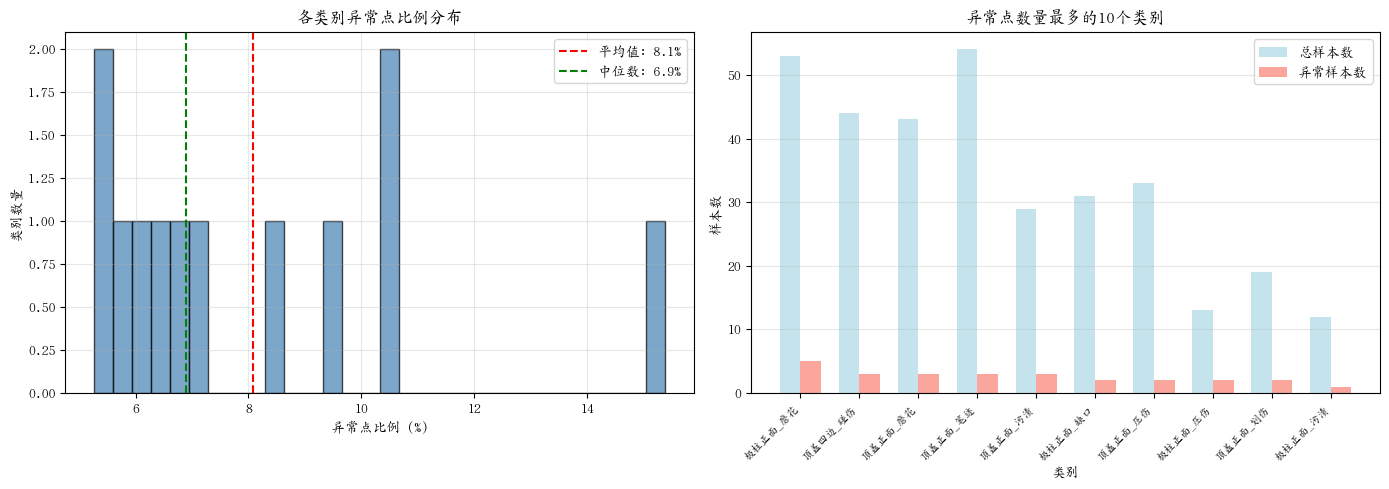

In [23]:
# 统计分析：异常点数量分布
print("=" * 80)
print("异常点统计分析")
print("=" * 80)

# 1. 按类别统计
print("\n1. 各类别异常点比例分布")
outlier_ratios = []
for label, count in label_outlier_counts.items():
    total = len(label_to_indices[label])
    ratio = count / total
    outlier_ratios.append(ratio)

outlier_ratios = np.array(outlier_ratios)
print(f"   平均异常比例: {np.mean(outlier_ratios)*100:.2f}%")
print(f"   中位数异常比例: {np.median(outlier_ratios)*100:.2f}%")
print(f"   最小异常比例: {np.min(outlier_ratios)*100:.2f}%")
print(f"   最大异常比例: {np.max(outlier_ratios)*100:.2f}%")

# 2. 可疑样本统计
print(f"\n2. 可能标注错误的样本")
print(f"   高相似度样本数 (>={HIGH_SIMILARITY_THRESHOLD}): {len(suspicious_samples)}")
if len(suspicious_samples) > 0:
    avg_sim = np.mean([s['similarity_to_suggested'] for s in suspicious_samples])
    print(f"   平均相似度: {avg_sim:.4f}")

# 3. 异常点迁移方向分析
print(f"\n3. 异常点最常混淆的类别对")
confusion_pairs = {}
for item in outlier_analysis:
    if len(item['most_similar_labels']) > 0:
        current_label = item['label']
        suggested_label = item['most_similar_labels'][0][0]
        pair = (current_label, suggested_label)
        confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

# 按混淆次数排序
sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)
print("   Top 10 混淆类别对:")
for i, ((label1, label2), count) in enumerate(sorted_pairs[:10], 1):
    print(f"   {i:2d}. {label1} → {label2}: {count} 次")

print("\n" + "=" * 80)

# 可视化异常点比例分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 异常点比例分布直方图
axes[0].hist(outlier_ratios * 100, bins=30, alpha=0.7, edgecolor='black', color='steelblue')
axes[0].axvline(np.mean(outlier_ratios) * 100, color='r', linestyle='--', label=f'平均值: {np.mean(outlier_ratios)*100:.1f}%')
axes[0].axvline(np.median(outlier_ratios) * 100, color='g', linestyle='--', label=f'中位数: {np.median(outlier_ratios)*100:.1f}%')
axes[0].set_xlabel('异常点比例 (%)')
axes[0].set_ylabel('类别数量')
axes[0].set_title('各类别异常点比例分布')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图: 异常点数量最多的类别
top_10_labels = [label for label, _ in sorted_counts[:10]]
top_10_counts = [count for _, count in sorted_counts[:10]]
top_10_totals = [len(label_to_indices[label]) for label in top_10_labels]

x = np.arange(len(top_10_labels))
width = 0.35

bars1 = axes[1].bar(x - width/2, top_10_totals, width, label='总样本数', alpha=0.7, color='lightblue')
bars2 = axes[1].bar(x + width/2, top_10_counts, width, label='异常样本数', alpha=0.7, color='salmon')

axes[1].set_xlabel('类别')
axes[1].set_ylabel('样本数')
axes[1].set_title('异常点数量最多的10个类别')
axes[1].set_xticks(x)
axes[1].set_xticklabels([label[:15] + '...' if len(label) > 15 else label for label in top_10_labels], 
                         rotation=45, ha='right', fontsize=8)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [15]:
# # 将结果导出为JSON文件，方便后续使用
# import json
# from pathlib import Path

# # 准备导出的数据
# export_data = {
#     'summary': {
#         'total_samples': len(embeddings),
#         'total_categories': len(unique_labels),
#         'categories_analyzed': len(all_results),
#         'total_outliers': len(outlier_analysis),
#         'suspicious_samples': len(suspicious_samples),
#         'outlier_threshold_percentile': OUTLIER_THRESHOLD_PERCENTILE,
#         'contamination': CONTAMINATION
#     },
#     'outlier_analysis': outlier_analysis,
#     'suspicious_samples': suspicious_samples,
#     'category_statistics': {
#         label: {
#             'total_samples': len(label_to_indices[label]),
#             'outlier_count': label_outlier_counts.get(label, 0),
#             'outlier_ratio': label_outlier_counts.get(label, 0) / len(label_to_indices[label])
#         }
#         for label in unique_labels
#         if label in all_results
#     }
# }

# # 保存到文件
# npz_filename = Path(npz_path).stem
# output_path = Path(npz_path).parent / f"{npz_filename}_outlier_analysis.json"

# with open(output_path, 'w', encoding='utf-8') as f:
#     json.dump(export_data, f, ensure_ascii=False, indent=2)

# print(f"✓ 结果已导出到: {output_path}")
# print(f"  - 总异常点数: {len(outlier_analysis)}")
# print(f"  - 可疑样本数: {len(suspicious_samples)}")
# print(f"  - 分析类别数: {len(all_results)}")

# 导出结果